# Deep Learning U-Net Baseline

Train a 12-band U-Net-style semantic segmentation model on the land cover dataset, evaluate it with the same style as the classical notebook, and visualize several held-out test scenes.

In [9]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "samples_generated"
if not DATA_DIR.exists():
    DATA_DIR = ROOT / "data" / "samples_prepared"

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {1: "Greenery", 2: "Sand", 3: "Water", 4: "Cement"}
CLASS_IDS = list(CLASS_NAMES)
TARGET_NAMES = [CLASS_NAMES[i] for i in CLASS_IDS]
COLORS = np.array([
    [0, 0, 0],
    [0, 100, 0],
    [184, 134, 11],
    [0, 0, 139],
    [105, 105, 105],
], dtype=np.uint8)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4


def device_is_usable(device):
    layer = nn.Conv2d(12, 8, 3, padding=1).to(device)
    x = torch.randn(1, 12, 64, 64, device=device)
    with torch.no_grad():
        _ = layer(x)


def choose_device():
    candidates = []

    if torch.cuda.is_available():
        candidates.append(torch.device("cuda"))

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        candidates.append(torch.device("mps"))

    candidates.append(torch.device("cpu"))
    last_error = None

    for device in candidates:
        try:
            device_is_usable(device)
            return device
        except Exception as e:
            print(f"Skipping {device}: {e}")
            last_error = e

            if device.type == "cpu" and torch.backends.mkldnn.enabled:
                print("Retrying CPU with mkldnn disabled...")
                torch.backends.mkldnn.enabled = False
                try:
                    device_is_usable(device)
                    return device
                except Exception as e2:
                    print(f"CPU retry failed: {e2}")
                    last_error = e2

    raise RuntimeError(f"No usable torch device found: {last_error}")


DEVICE = choose_device()
RNG = np.random.default_rng(42)
DEVICE

Skipping cuda: GET was unable to find an engine to execute this computation


device(type='cpu')

In [10]:
def load_sample(row):
    with rio.open(row.spectral_path) as src:
        spectral = src.read().astype("float32")

    with rio.open(row.mask_path) as src:
        mask = src.read(1).astype("uint8")

    return spectral, mask


def scale_input(spectral):
    return np.clip(spectral / 10000.0, 0, 1)


def resize_scene(spectral, mask, size=IMAGE_SIZE):
    x = torch.from_numpy(spectral)
    y = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)

    x = F.interpolate(x.unsqueeze(0), size=(size, size), mode="bilinear", align_corners=False).squeeze(0)
    y = F.interpolate(y.unsqueeze(0), size=(size, size), mode="nearest").squeeze(0).squeeze(0).long()

    return x, y


def prepare_scene(spectral, mask, mean, std, size=IMAGE_SIZE):
    spectral = scale_input(spectral)
    raw_x, y = resize_scene(spectral, mask, size=size)
    x = (raw_x - mean[:, None, None]) / std[:, None, None]
    return x, y, raw_x


def rgb_preview(spectral):
    rgb = np.moveaxis(spectral[[3, 2, 1]], 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - low) / (high - low + 1e-6), 0, 1)


def colorize(mask):
    return COLORS[mask]


def compute_band_stats(frame):
    total = np.zeros(12, dtype=np.float64)
    total_sq = np.zeros(12, dtype=np.float64)
    pixels = 0

    for row in frame.itertuples(index=False):
        spectral, _ = load_sample(row)
        spectral = scale_input(spectral).reshape(12, -1)
        total += spectral.sum(axis=1)
        total_sq += (spectral ** 2).sum(axis=1)
        pixels += spectral.shape[1]

    mean = total / pixels
    std = np.sqrt(np.clip(total_sq / pixels - mean ** 2, 1e-8, None))
    return torch.tensor(mean, dtype=torch.float32), torch.tensor(std, dtype=torch.float32)


def compute_class_weights(frame):
    counts = np.zeros(5, dtype=np.int64)

    for row in frame.itertuples(index=False):
        _, mask = load_sample(row)
        counts += np.bincount(mask.reshape(-1), minlength=5)

    weights = np.zeros(5, dtype=np.float32)
    active = np.maximum(counts[1:], 1)
    weights[1:] = active.sum() / active
    weights[1:] /= weights[1:].mean()

    return counts, torch.tensor(weights, dtype=torch.float32)

In [11]:
samples = []

for spectral_path in sorted(DATA_DIR.glob("*/*_Spectral.tif")):
    sample = spectral_path.parent.name
    mask_path = spectral_path.with_name(f"{sample}_Mask.tif")
    if mask_path.exists():
        samples.append({
            "sample": sample,
            "spectral_path": spectral_path,
            "mask_path": mask_path,
        })

samples = pd.DataFrame(samples)
samples

,sample,spectral_path,mask_path
0,6thOfOctoberCity,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
1,AbuSimbel,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
2,AinSokhna,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
3,AlKhargaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
4,Alexandria,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
5,Asyut,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
6,BahariyaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
7,BeniSuef,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
8,CairoUniv,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
9,DakhlaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...


In [12]:
outer = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_val_idx, test_idx = next(outer.split(samples, groups=samples["sample"]))

train_val_df = samples.iloc[train_val_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(inner.split(train_val_df, groups=train_val_df["sample"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"val scenes: {len(val_df)}")
print(val_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())

train scenes: 25
['6thOfOctoberCity', 'AbuSimbel', 'AinSokhna', 'Asyut', 'BeniSuef', 'DakhlaOasis', 'EastPortSaidPort', 'ElAlamein', 'Farafra', 'GreatPyramidOfGiza', 'HawaraFayoum', 'Hurghada', 'IconicTower', 'KarnakLuxor', 'LakeBardawil', 'LakeQarun', 'MarsaAlam', 'MarsaMatrouh', 'Minya', 'NewAlamein', 'PhilaeAswan', 'Qena', 'RashidRosetta', 'SiwaOasis', 'WadiElNatrun']

val scenes: 7
['ElGouna', 'Faiyum', 'Ismailia', 'KomOmbo', 'NewCairo', 'SuezPort', 'ToshkaLakes']

test scenes: 11
['AlKhargaOasis', 'Alexandria', 'BahariyaOasis', 'CairoUniv', 'ElArish', 'LakeBurullus', 'LakeManzala', 'RasMuhammadNationalPark', 'SaintCatherine', 'SharqElOwainat', 'Sohag']


In [13]:
band_mean, band_std = compute_band_stats(train_df)
class_counts, class_weights = compute_class_weights(train_df)

print("band mean:")
display(pd.Series(band_mean.numpy()).rename("mean"))
print()
print("class counts:")
display(pd.DataFrame({
    "class_id": list(range(5)),
    "count": class_counts,
    "weight": class_weights.numpy(),
}))

band mean:


0     0.127202
1     0.152732
2     0.205284
3     0.249105
4     0.281280
5     0.303818
6     0.317113
7     0.323444
8     0.323647
9     0.328576
10    0.349200
11    0.305127
Name: mean, dtype: float32


class counts:


,class_id,count,weight
0,0,13237,0.000000
1,1,264064,1.413888
2,2,911055,0.409807
3,3,353492,1.056196
4,4,333322,1.120109


In [14]:
class SceneDataset(Dataset):
    def __init__(self, frame, mean, std, train=False, size=IMAGE_SIZE):
        self.frame = frame.reset_index(drop=True)
        self.mean = mean.clone()
        self.std = std.clone()
        self.train = train
        self.size = size

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        spectral, mask = load_sample(row)
        x, y, _ = prepare_scene(spectral, mask, self.mean, self.std, size=self.size)

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
            y = torch.flip(y, dims=[1])

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[1])
            y = torch.flip(y, dims=[0])

        return x, y


train_ds = SceneDataset(train_df, band_mean, band_std, train=True)
val_ds = SceneDataset(val_df, band_mean, band_std, train=False)
test_ds = SceneDataset(test_df, band_mean, band_std, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

len(train_ds), len(val_ds), len(test_ds)

(25, 7, 11)

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_ch=12, out_ch=5, base=32):
        super().__init__()
        self.inc = DoubleConv(in_ch, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.bottleneck = Down(base * 8, base * 16)
        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)
        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


model = UNet().to(DEVICE)
model

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def run_epoch(loader, train_mode):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1).detach().cpu().numpy()
        true = y.detach().cpu().numpy()
        valid = true > 0
        if valid.any():
            cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)

    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    miou = (intersection / np.maximum(union, 1)).mean()

    return total_loss / len(loader.dataset), float(miou)


history = []
best_val_miou = -1.0
model_path = MODEL_DIR / "unet_baseline.pt"

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    train_loss, train_miou = run_epoch(train_loader, train_mode=True)
    val_loss, val_miou = run_epoch(val_loader, train_mode=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_miou": train_miou,
        "val_loss": val_loss,
        "val_miou": val_miou,
    })

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({
            "model_state": model.state_dict(),
            "band_mean": band_mean,
            "band_std": band_std,
            "history": history,
        }, model_path)

history_df = pd.DataFrame(history)
history_df

Training:   0%|          | 0/20 [00:00<?, ?it/s]

,epoch,train_loss,train_miou,val_loss,val_miou
0,1,1.459400,0.316163,1.590855,0.215849
1,2,1.142672,0.554832,1.435301,0.337211
2,3,1.011643,0.571915,1.188937,0.680436
3,4,0.929628,0.641416,0.928013,0.714650
4,5,0.892905,0.643674,0.738427,0.743528
5,6,0.825492,0.679660,0.628210,0.741096
6,7,0.909993,0.626605,0.456963,0.741932
7,8,0.996831,0.520486,0.483329,0.735721
8,9,0.967498,0.566743,0.531021,0.726910
9,10,0.933552,0.611045,0.540444,0.715294


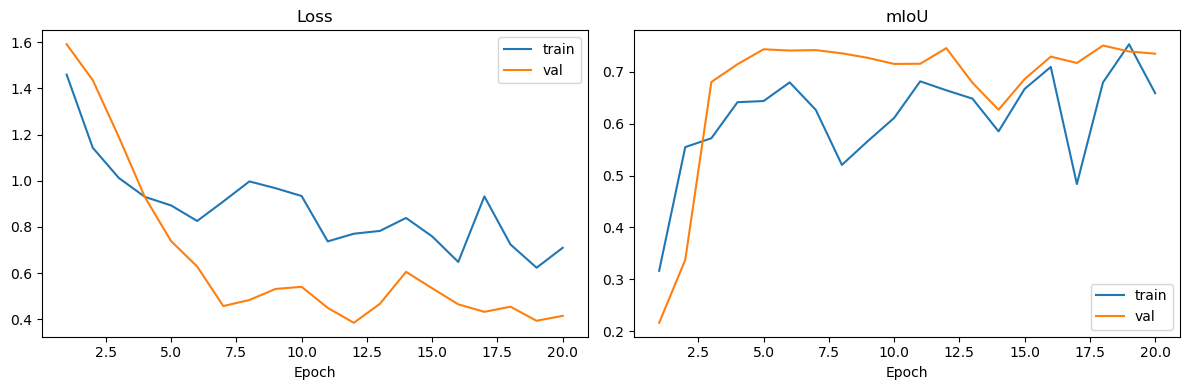

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
ax[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history_df["epoch"], history_df["train_miou"], label="train")
ax[1].plot(history_df["epoch"], history_df["val_miou"], label="val")
ax[1].set_title("mIoU")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

In [18]:
checkpoint = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
all_y_true = []
all_y_pred = []

for row in test_df.itertuples(index=False):
    spectral, mask = load_sample(row)
    x, y, _ = prepare_scene(spectral, mask, band_mean, band_std)

    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))

    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    true = y.numpy()

    all_y_true.extend(true.reshape(-1))
    all_y_pred.extend(pred.reshape(-1))

    valid = true > 0
    cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
valid_indices = np.isin(all_y_true, CLASS_IDS)

intersection = np.diag(cm)
union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
iou = intersection / np.maximum(union, 1)

metrics = pd.DataFrame({
    "class_id": CLASS_IDS,
    "class_name": TARGET_NAMES,
    "IoU": iou,
    "support": cm.sum(axis=1),
}).sort_values("class_id")

print(f"mIoU: {metrics['IoU'].mean():.3f}")
display(metrics)
print()
print("Classification report")
print(classification_report(
    all_y_true[valid_indices],
    all_y_pred[valid_indices],
    labels=CLASS_IDS,
    target_names=TARGET_NAMES,
    zero_division=0,
))

mIoU: 0.795


,class_id,class_name,IoU,support
0,1,Greenery,0.683362,72415
1,2,Sand,0.822165,279333
2,3,Water,0.972382,168491
3,4,Cement,0.703785,176142



Classification report
              precision    recall  f1-score   support

    Greenery       0.78      0.85      0.81     72415
        Sand       0.95      0.86      0.90    279333
       Water       0.98      0.99      0.99    168491
      Cement       0.78      0.88      0.83    176142

    accuracy                           0.89    696381
   macro avg       0.87      0.89      0.88    696381
weighted avg       0.90      0.89      0.89    696381



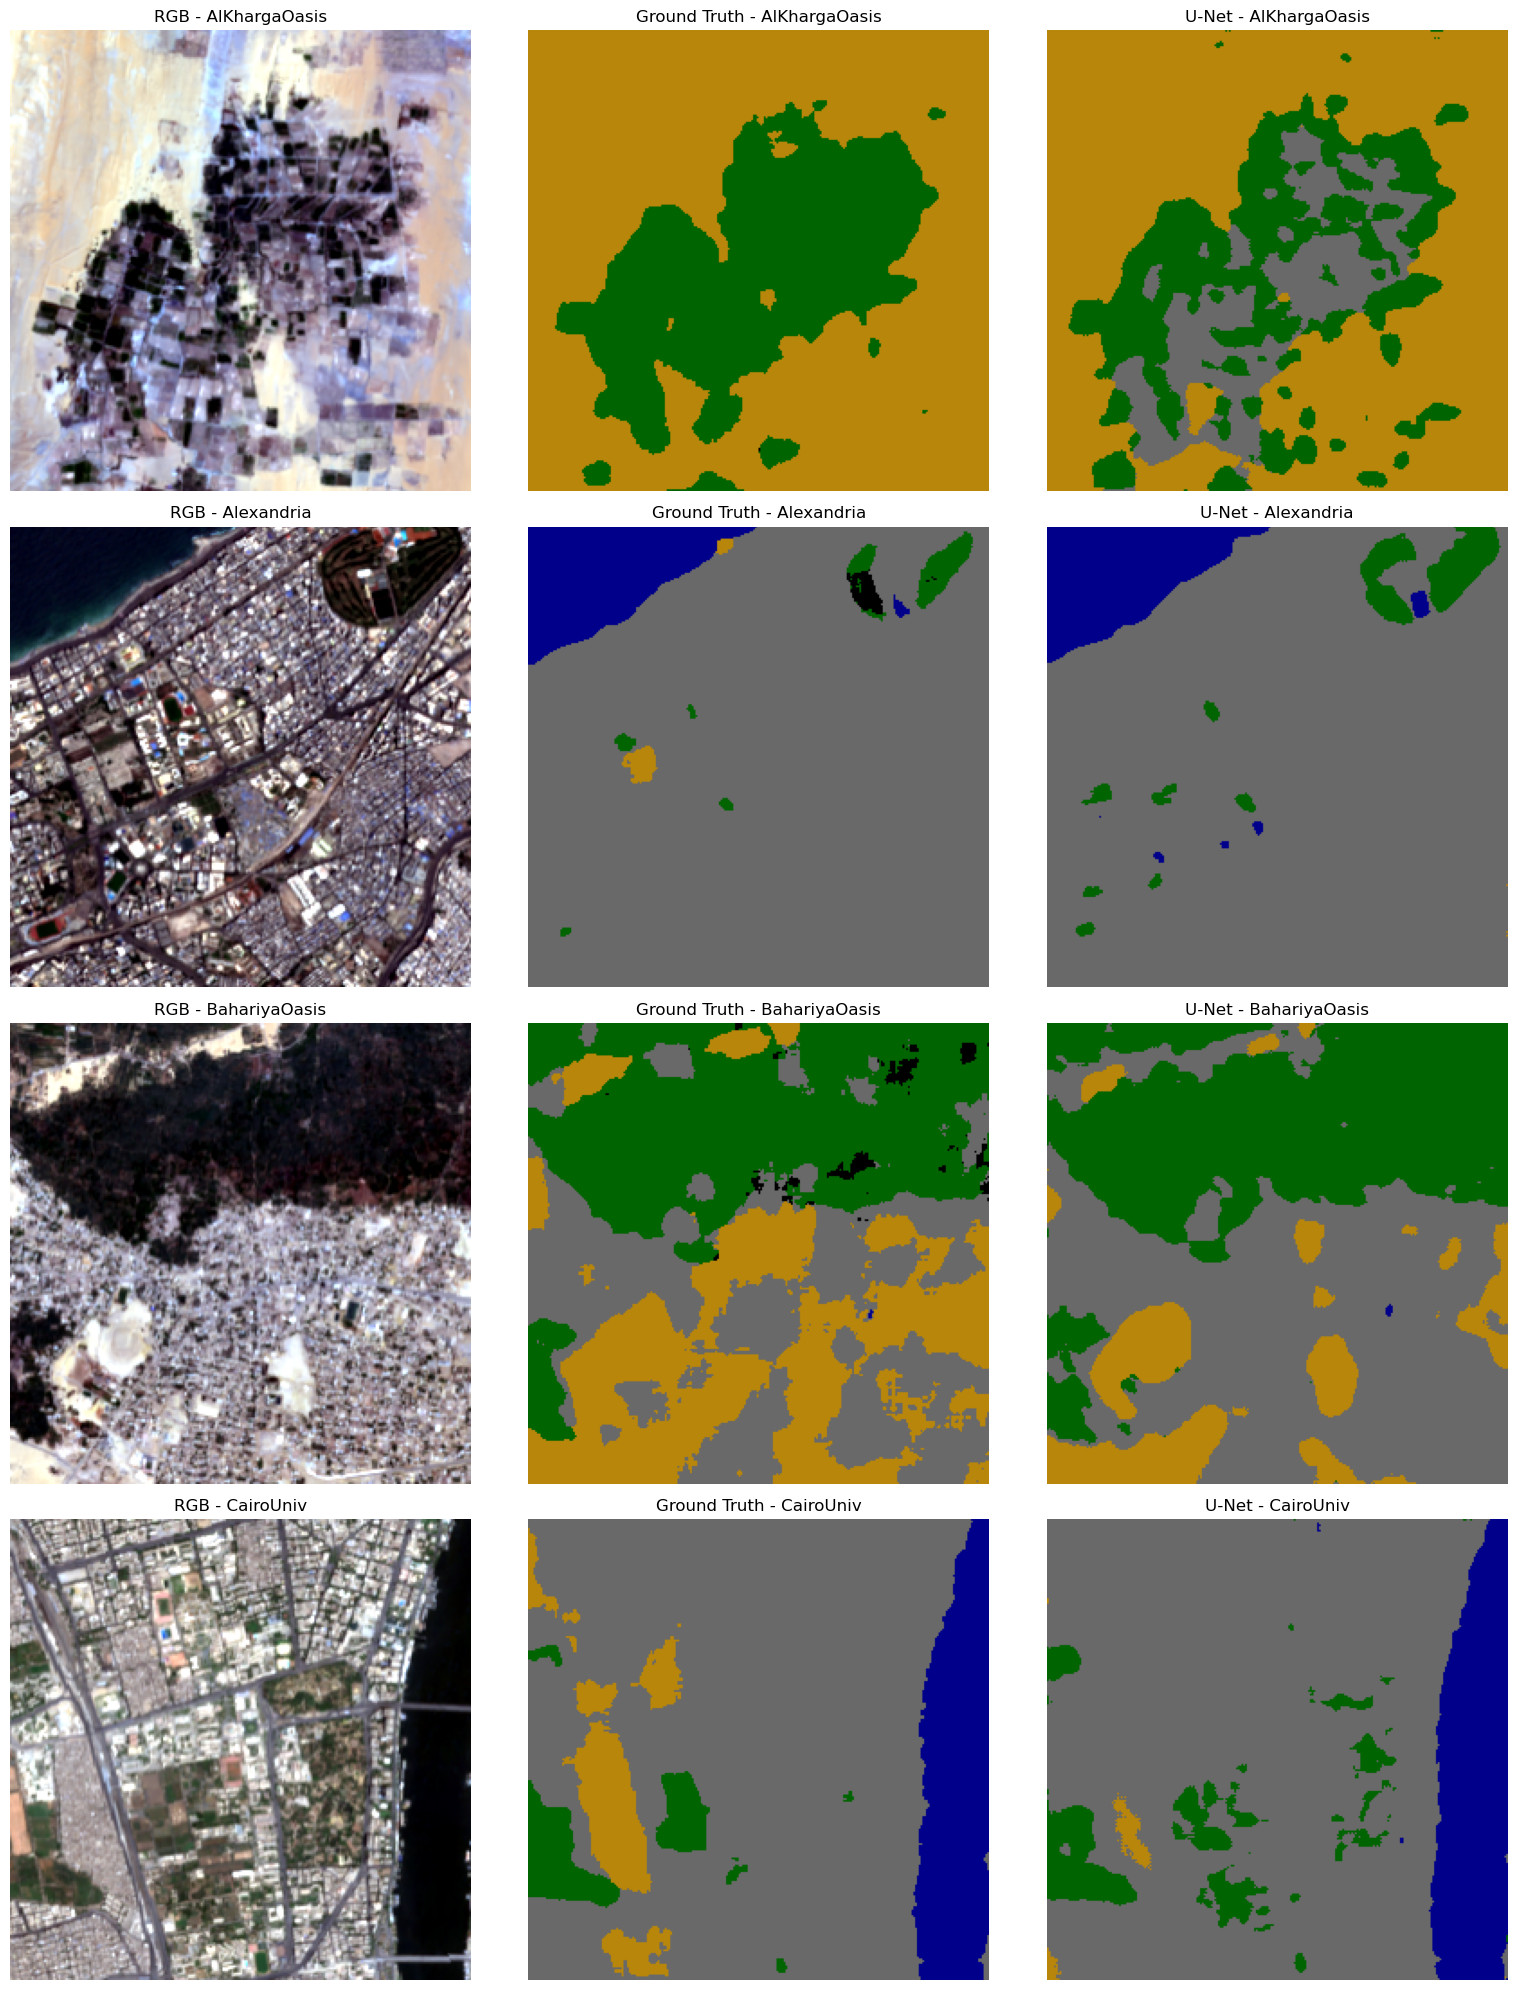

In [19]:
n_show = min(4, len(test_df))
rows = test_df.iloc[:n_show]

fig, ax = plt.subplots(n_show, 3, figsize=(16, 5 * n_show))
if n_show == 1:
    ax = np.array([ax])

for i, row in enumerate(rows.itertuples(index=False)):
    spectral, mask = load_sample(row)
    x, y, raw_x = prepare_scene(spectral, mask, band_mean, band_std)

    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))

    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    true = y.numpy().astype(np.uint8)
    raw = raw_x.numpy()

    ax[i, 0].imshow(rgb_preview(raw))
    ax[i, 0].set_title(f"RGB - {row.sample}")

    ax[i, 1].imshow(colorize(true))
    ax[i, 1].set_title(f"Ground Truth - {row.sample}")

    ax[i, 2].imshow(colorize(pred))
    ax[i, 2].set_title(f"U-Net - {row.sample}")

    for a in ax[i]:
        a.axis("off")

plt.tight_layout()
plt.show()